In [ ]:
#step1: Importing libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("spotify2019.csv")

In [ ]:
X = df.drop(columns=['artist_name', 'track_id', 'track_name'], errors='ignore') # Features

print(df.columns)

Index(['artist_name', 'track_id', 'track_name', 'acousticness', 'danceability',
       'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness',
       'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence',
       'popularity'],
      dtype='object')


In [ ]:
y_binary = (df['popularity'] > df['popularity'].median()).astype(int)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_binary,
    test_size=0.2, random_state=42, stratify=y_binary
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2, random_state=42, stratify=y_train_val
)

In [ ]:
model.evaluate(X_test,y_test)

817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 926us/step - accuracy: 0.9563 - loss: 0.0844


[0.08417671173810959, 0.9573718905448914]

In [ ]:
def build_model(learning_rate=0.001,):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, input_shape=(784,),activation='relu'),
        Dense(10, activation='softmax')  # binary classification
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9732 - loss: 0.0744
Epoch 2/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9721 - loss: 0.0733
Epoch 3/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9760 - loss: 0.0737
Epoch 4/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9725 - loss: 0.0758
Epoch 5/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9710 - loss: 0.0805
Epoch 6/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9748 - loss: 0.0642
Epoch 7/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9704 - loss: 0.0837
Epoch 8/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9746 - loss: 0.0692
Epoch 9/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9722 - loss: 0.0726
Epoch 10/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9730 - loss: 0.0751


In [ ]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.7).astype("int32")  # try 0.6–0.8

817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 651us/step


In [ ]:
model.fit(X_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9748 - loss: 0.0686
Epoch 2/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9771 - loss: 0.0630
Epoch 3/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9747 - loss: 0.0741
Epoch 4/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9705 - loss: 0.0819
Epoch 5/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9753 - loss: 0.0661
Epoch 6/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9759 - loss: 0.0666
Epoch 7/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9737 - loss: 0.0694
Epoch 8/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9747 - loss: 0.0682
Epoch 9/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9748 - loss: 0.0717
Epoch 10/10
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9740 - loss: 0.0661


In [ ]:
model.evaluate(X_test,y_test)

817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.9809 - loss: 0.0560


[0.05582611262798309, 0.9816706776618958]

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)


817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step


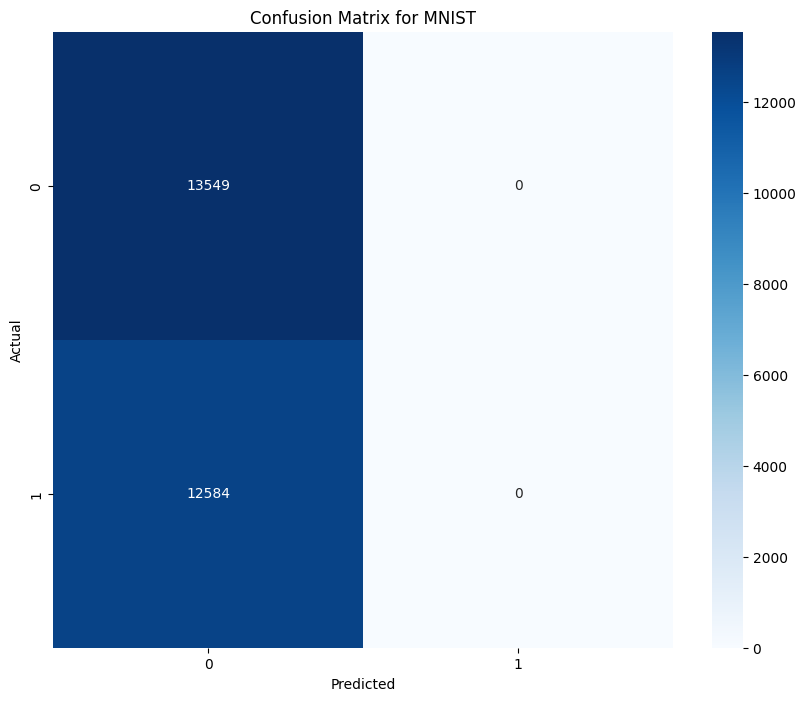

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(2), yticklabels=range(2))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for MNIST')
plt.show()


In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.52      1.00      0.68     13549
           1       0.00      0.00      0.00     12584

    accuracy                           0.52     26133
   macro avg       0.26      0.50      0.34     26133
weighted avg       0.27      0.52      0.35     26133



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def build_model(learning_rate=0.001):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model